# Lecture 1: Introduction to Language Models

In this lecture, we will introduce the basics of language models. We'll cover next-token prediction and the transformer architecture, with an eye towards using what we know about language models to better understand how they work internally.

### ✍ Learning goals

By the end of the lesson, we hope you take away the following.

* **Autoregressive nature of LMs**: language models predict tokens one at a time.
* **The transformer architecture**: understand the basics of the current popular architecture for language models, including MLP and attention.
* **The 🤗 Transformers library**: learn how to load and inspect the latest open-source models with the Transformers library.

## 0️⃣ Setup

Run this code to get started!

In [ ]:
from IPython.display import clear_output
import plotly.io as pio

try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    pio.renderers.default = "colab"
    !git clone https://github.com/cs221m/cs221m-course.git
    %cd cs221m-course
    !uv sync
else:
    pio.renderers.default = "plotly_mimetype+png"
    !uv sync
    !plotly_get_chrome -y

clear_output()

## 1️⃣ Talking to language models

### The gameplan

In this lecture we'll peel back the internals of a language model one curtain at a time. We'll start by treating the model as a complete black-box, and end with understanding specific parameters such as the weights inside MLP and attention layers.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/main.gif" width="1000" alt="black-box llm"/>

The goal isn't so much to dwell on each design decision of the transformer architecture - there's whole other classes dedicated to this! Instead, this review will go through what makes a transformer, with an eye towards thinking about what computational function each component might serve in large pre-trained models.

Let's dive right in!

### Playing around with a language model

First and foremost, it's good to get acquainted with language models even just as black boxes. There's lots we can learn about an LLM simply from talking to it! 

Throughout this lecture, we'll use a black-and-purple rectangle whenever we want to refer to a "black-box" part of the language model that we'll later uncover. To begin with, all we need to know about language models is that they take in some text as input and output the token that's most likely to follow that text (this is true even for instruct and reasoning models, albeit with different meanings of "likely"!).

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/lm.png" width="500" alt="black-box llm"/>

Without further ado, let's chat with one such language model. We'll load `gpt-2`, an open-source model released by OpenAI in 2019. As you'll see from playing with it, times have changed quickly in the world of AI!

In [2]:
# the code below loads gpt2 for us to play with
from transformers import pipeline

gpt2 = pipeline("text-generation", model="gpt2", device_map='cuda')

clear_output()

The pre-trained models we'll be working with in this lesson are *base* models. These models predict the next token in a sequence - if you start a sentence, the model will try to complete it for you.

In [ ]:
# try messing around with the prompt!
output = gpt2(
    'Once upon a time',
    max_new_tokens=20 # this controls how much text we want to generate
)

clear_output() # ignore warnings

# let's see how your model response!
print(output[0]['generated_text'])

Once upon a time, we had just given birth to a child, and we were in the midst of a terrible disaster


### ✏ **Exercise 1**

Play around with the model! What can it do? What can't it do? This is the ancestor of GPT-5 (the latest at the time of writing). What are some of the differences that you notice?

*Hint: What facts does it know about the world? Can it do basic math? How can you tell?*

In [ ]:
# try messing around with the prompt!
output = gpt2(
    # your code here!
)

# let's see how your model response!
print(output[0]['generated_text'])

What are 3 capabilities you notice? What are 3 things that the model struggles with?

> FILL IN YOUR ANSWER HERE

In [4]:
# when you're done, delete the model from this previous section
# and move on to the next section!
del gpt2

### Peeling back a layer: tokens and logits

Time to peel back a single layer of our model. We won't yet reveal the large "black-box", but let's get a bit more specific with what we mean by inputs and outputs.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/lm_with_tokens.png" width="500" alt="black-box llm with tokens/logits"/>

How does the model actually represent text? In this section, we'll see how text gets represented as **tokens**, and that the model predicts a **distribution** over the next token in a sentence.

To do this, let's load `gpt-2` once again. Notice that this time, there's a separate `tokenizer` and `model` component.

In [5]:
# this time, let's load the model and tokenizer separately
from transformers import AutoTokenizer, AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("gpt2").to("cuda")
tokenizer = AutoTokenizer.from_pretrained("gpt2")

clear_output()

How is the text that we input to the model represented? The **tokenizer** parses a string of text into individual **tokens**. Each token has its own unique **token id**.

Although there's many details into what makes a tokenizer (and what makes a good tokenizer!), we can think of this as nothing more than a look-up table from tokens to unique numbers, which we'll call **input ids**. Looks like our tokenizer has $50257$ unique tokens in its look-up table - remember this number, because it'll come back again soon!

In [6]:
# note: the Ġ is an artifact of gpt-2
# however, it's often the case that " token" is different from "token"!
tokens = tokenizer.tokenize("The Eiffel Tower is in the city of")
token_ids = tokenizer("The Eiffel Tower is in the city of")["input_ids"]

print("Vocabulary size of our tokenizer:", tokenizer.vocab_size)
print("Number of tokens in our input:", len(token_ids))
print()
print("Tokens:", tokens)
print("Token ids:", token_ids)

Vocabulary size of our tokenizer: 50257
Number of tokens in our input: 10

Tokens: ['The', 'ĠE', 'iff', 'el', 'ĠTower', 'Ġis', 'Ġin', 'Ġthe', 'Ġcity', 'Ġof']
Token ids: [464, 412, 733, 417, 8765, 318, 287, 262, 1748, 286]


A language model operates on input ids (the token ids of the text we input to the model). Every language model takes in a list of input ids, and outputs a **probability distribution** over the **next token** in the sequence.

Let's look at what that output distribution looks like.

In [7]:
import torch

# this time, let's return the input ids as a tensor instead of as a list
# (it still has the same exact values!)
input_ids = tokenizer("The Eiffel Tower is in the city of", return_tensors="pt")["input_ids"]

with torch.no_grad(): # disable gradient
    # we pass the input ids into the model to get its prediction for the next token
    outputs = model(input_ids=input_ids.to(model.device)).logits[0]

outputs.shape

torch.Size([10, 50257])

What we got from the model is a very large matrix: $(10 \times 50257)$. Do these numbers look similar to you? Hopefully, you'll notice that this shape matches $(\text{number of input tokens} \times \text{vocabulary size})$.

We'll explain these numbers one at a time.

The $10$ isn't important just yet: our model is processing the text *in parallel*, so it's making a prediction for each token at the same time. This parallelism makes the model efficient, and we'll talk more about it in the next section.

The $50257$ represents our entire vocabulary (notice it's also the size of our tokenizer!). The language model outputs a list of numbers, one for each vocabulary item, that represents how likely that item is to be the next token. When we take the [softmax](https://en.wikipedia.org/wiki/Softmax_function) of these weights, we get a *probability distribution* over what the next token in the vocabulary is.

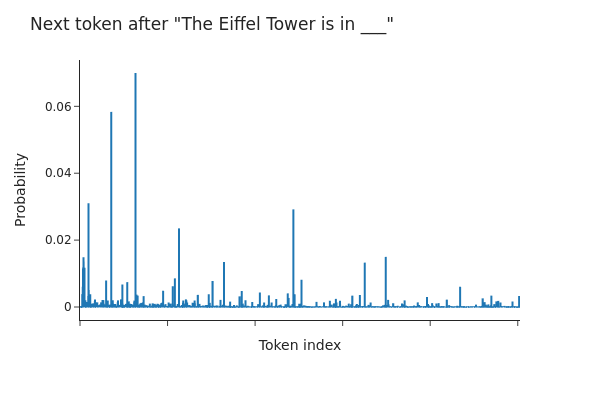

In [8]:
import plotly.express as px

# guessing the next token
next_token_probability = outputs[-1] # (50527,)
# softmax gives us a distribution (sums up to 1)
next_token_probability = next_token_probability.softmax(dim=-1) # (50527,)

fig = px.line(
    x = range(len(next_token_probability)),
    y = next_token_probability.cpu().numpy(),
    template = 'simple_white',
    width = 600,
    height = 400
)

# prettify
fig.update_layout(xaxis=dict(showticklabels=False,
                             title='Token index'),
                  yaxis=dict(title='Probability'),
                  title="Next token after \"The Eiffel Tower is in ___\"")

fig.show()

The plot above doesn't tell us too much (since each token is unique, there's no real meaning to the x-axis), but we can see that there's a handful of tokens that the model predicts are likely to follow our prompt. Let's see which tokens the model predicts.

In [9]:
print("The Eiffel Tower is in the city of")

# print the top 3 tokens, in order of their probabilities
most_likely_tokens = torch.topk(next_token_probability, 3, sorted=True)
for v, i in zip(most_likely_tokens.values, most_likely_tokens.indices):
    print(f'{tokenizer.decode(i.item())} ({v.item():.2f})')

The Eiffel Tower is in the city of
 Paris (0.07)
 London (0.06)
 New (0.03)


We can also get the most likely token using the `argmax` function. Since `argmax` gives us the **index** of the most likely token, we can use the tokenizer to **decode** the model's prediction from a token index to the actual token.

When we generate text from a model, we can choose whether we want to sample from the model's output distribution, or just take the `argmax` of the distribution for every new token (sometimes called greedy decoding).

In [10]:
print("Prompt: \"The Eiffel Tower is in the city of\"")

output_token = tokenizer.decode(next_token_probability.argmax(dim=-1))
print(f"Output: \"{output_token}\"")

Prompt: "The Eiffel Tower is in the city of"
Output: " Paris"


The keen observer might notice something a little odd about the output token we got from `gpt` - it has a space at the beginning! The `gpt-2` model, along with many other language models, prefers to tokenize words alongside a space. Since the end of our prompt doesn't have a space, the next token starts with one. Interestingly enough, whether or not you have a space at the end of your text matters a lot to these models - the token sequence no longer looks the same!

In [11]:
token_ids_no_space = tokenizer(" Paris")["input_ids"]
token_ids_with_space = tokenizer("Paris")["input_ids"]

print("Paris with a sapce:", token_ids_no_space)
print("Paris without a space:", token_ids_with_space)

Paris with a sapce: [6342]
Paris without a space: [40313]


### ✏ **Exercise 2**

Get the model's predictions when we input the same prompt as above, but with a space at the end:

"The Eiffel Tower is in the city of "

What are the model's top three token predictions?

*Hint: You're more than encouraged to copy-paste code from the cells above!*

In [13]:
# same as before, but with a space at the end of the prompt
input_ids = tokenizer("The Eiffel Tower is in the city of ", return_tensors="pt")["input_ids"]

# your code here!

What are the top three tokens predicted by the model? Were they what you expected?

> FILL IN YOUR ANSWER HERE

### 🧠 Takeaways

In this section, we saw how models take in **token ids** as inputs and output a **probability distribution** over the next token in the sequence.

We also saw how little things like whitespace can throw off our model, because of how the text is tokenized! In the next section, we'll continue breaking down the model, this time looking into its internal computations.

Run this code when you're done with this section - we'll explore a different model in the next section.

In [12]:
del model # delete gpt2 to make space for the next model!

## 2️⃣ The anatomy of language models

### Looking inwards

In the previous section, we peeled back a single layer, looking at how the input and output text are encoded by language models.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/lm_with_tokens.png" width="500" alt="black-box llm with tokens/logits"/>

In this section, we'll take a look at the internals of a language model - this is the **transformer** architecture. We'll focus on how information flows from input to output in a transformer model, looking at the following components:
1. Residual stream - the intermediate activation between each full layer block.
2. MLP - the dense processing layer within each layer block.
3. Attention - the mechanism for information to flow between different input tokens.

### Inspecting model internals

Let's go ahead and "open the blackbox" to explore the internal computation of language models. At the end of the day, it's all numbers! But that doesn't immediately suggest we understand what these numbers mean...

We'll also get to explore our first library for interpretability, [`nnsight`](https://nnsight.net/)! This library is fantastic for getting hands-on with model internals - we strongly encourage checking out the tutorials on the [`nnsight` website](https://nnsight.net/tutorials/). Make sure that you ran the code in the Setup section to install the `nnsight` library.

For this section, we'll use a smaller but more recent model, whose architecture will be easier to explain. Everything we covered in the last section - tokenization and output logits - also applies to this model!

You can explore a range of open-source models in the [🤗 Transformers](https://huggingface.co/) website.

In [13]:
from nnsight import LanguageModel

model = LanguageModel("HuggingFaceTB/SmolLM2-135M")

clear_output()

### Weights vs. Activations

Time to unveil the curtain!

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/lm_layers.png" width="800" alt="llm residual stream"/>

We make a point to distinguish between the **weights** (also called parameters) and **activations** (also called representations) of the model. In the visual above, the weights are still "black-box" to us (there's more to uncover behind each weight), and the activations are **vectors** - lists of numbers - with a consistent dimension (usually called the "hidden" dimension of the transformer).

Let's line up the visual with our code. When we print out our model, we see that it's made up of a few different parts:

* **Embedding layer**: This converts our token indices into vectors representing each token in the sequence.
* **Layers**: This is the core of our model. We'll unpack these layers step by step
* **LM head**: This projects the output from our final layer to predict the *logits* for the next token in the sequence.


In [14]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (rotary_emb): Lla

We can also see that inside each layer there's also an **attention** block and an **MLP**. We'll discuss these components in more detail over the course of the next few sections; for now, let's take a sneak peek inside one of these components.

The code below uses `nnsight` to inspect the model's internals. Let's quickly break it down:
```python
with model.trace("<INPUT>"):
  component = model.thing.we.want.to.inspect # component to inspect
  thing_to_save = component.output.save() # select: weight, input, or output 
```

Running `model.trace(...)` lets `nnsight` know we're tracing the internal computations of the model. To save something that we can access outside of the `trace` session, we must use `.save()`. We can choose what to save - `input`, `output`, or `weight` - and we'll discuss the meaning of these in this section.

In [15]:
# what's inside our model?
with model.trace("This is an example"):
  layer_10_mlp = model.model.layers[10].mlp.gate_proj
  layer_10_mlp_weight = layer_10_mlp.weight.save()

clear_output() # clear logs for loading model

layer_10_mlp_weight

Parameter containing:
tensor([[ 0.1025, -0.0850,  0.0097,  ...,  0.1113,  0.1943,  0.2793],
        [ 0.3359,  0.1147,  0.0131,  ...,  0.1963, -0.0369,  0.0457],
        [ 0.1426, -0.1426, -0.1797,  ..., -0.1206,  0.3555,  0.0786],
        ...,
        [ 0.0933, -0.0615,  0.0258,  ...,  0.0879, -0.1318,  0.0437],
        [-0.0464,  0.1377,  0.0503,  ...,  0.1953, -0.1416,  0.3496],
        [ 0.0732, -0.3086, -0.1367,  ...,  0.0049,  0.1621,  0.0104]],
       dtype=torch.bfloat16, requires_grad=True)

What's inside one part of our transformer, say the MLP in layer 10? It's huge matrix! In fact, it's matrices all the way down! Every component of the model contains **parameters**, or **weights**, that get applied to the inputs in order to predict the next token. Our model is nothing than just a large collection of numbers!

One important thing to note is that **model weights are static** - they don't change when we pass inputs into the model. No matter what input we pass in, the weights of the model will stay the same.

In [17]:
with model.trace("An entirely different input!"):
  layer_10_mlp_weight_1 = model.model.layers[10].mlp.gate_proj.weight.save()

layer_10_mlp_weight_1

Parameter containing:
tensor([[ 0.1025, -0.0850,  0.0097,  ...,  0.1113,  0.1943,  0.2793],
        [ 0.3359,  0.1147,  0.0131,  ...,  0.1963, -0.0369,  0.0457],
        [ 0.1426, -0.1426, -0.1797,  ..., -0.1206,  0.3555,  0.0786],
        ...,
        [ 0.0933, -0.0615,  0.0258,  ...,  0.0879, -0.1318,  0.0437],
        [-0.0464,  0.1377,  0.0503,  ...,  0.1953, -0.1416,  0.3496],
        [ 0.0732, -0.3086, -0.1367,  ...,  0.0049,  0.1621,  0.0104]],
       dtype=torch.bfloat16, requires_grad=True)

We can think of the **parameters** of the model kind of like the cells of our brain - for the most part (say, over the course of a day), they don't change. What changes is how these neurons **activate** when the brain receives different sensory inputs (like what lights up on an fMRI scan).

In other words, the components of the model stay the same, but the intermediate outputs of these components depend on what inputs they receive. We can see this when we change what we save from the `weight` of the component to its `output` activation.

In [19]:
# this time, we're saving outputs and not weights!
with model.trace("This is an example"):
  layer_10_mlp = model.model.layers[10].mlp.gate_proj.output.save()

with model.trace("An entire different input!"):
  layer_10_mlp_1 = model.model.layers[10].mlp.gate_proj.output.save()

print("MLP activation on input from example 1:")
print(layer_10_mlp)
print("MLP activation on input from example 2:")
print(layer_10_mlp_1)

MLP activation on input from example 1:
tensor([[[ 0.6094, -0.0728, -0.4785,  ..., -0.6406, -0.5742,  0.2129],
         [-0.1147,  0.2754, -0.2432,  ..., -0.0515, -1.5938,  0.1123],
         [-0.5234, -0.4395, -0.9531,  ..., -0.0552, -0.8672, -0.0640],
         [-0.2178,  0.3496, -0.5469,  ...,  0.4902, -0.9883, -0.7891]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)
MLP activation on input from example 2:
tensor([[[ 4.7656e-01, -4.1406e-01, -1.1953e+00,  ..., -4.1602e-01,
          -8.2812e-01,  5.6641e-01],
         [-9.2697e-04, -2.8125e-01,  2.2363e-01,  ..., -3.5156e-01,
          -1.1094e+00, -3.6914e-01],
         [ 2.8125e-01, -1.1562e+00, -6.1719e-01,  ..., -6.8750e-01,
          -6.8359e-01, -1.2656e+00],
         [-4.1797e-01, -1.4160e-01,  1.1084e-01,  ..., -1.7480e-01,
          -5.4297e-01, -4.8828e-01],
         [ 1.2891e-01, -7.1484e-01,  4.5312e-01,  ..., -5.1953e-01,
          -1.1250e+00, -4.9219e-01]]], dtype=torch.bfloat16,
       grad_fn=<UnsafeVie

In this lecture, we'll visualize **weights** with "black-box"-like black-and-purple rectangles, and visualize the intermediate **activations** as large thin vectors (with a different color for each token). In most schematic visualizations of neural networks, only the **activations** are visualized. In fact, going forward, we'll only print out or inspect the **activations** of the transformer model (and most interpretability methods we'll look at will only deal with activations). A key message to take away here, though, is that every activation is the output of some parameter of the model; but whereas activations change for different inputs we pass in, parameters do not.

### The residual stream

Earlier, we saw that a transformer model is made up of many different layers:

In [20]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 576)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=576, out_features=576, bias=False)
          (k_proj): Linear(in_features=576, out_features=192, bias=False)
          (v_proj): Linear(in_features=576, out_features=192, bias=False)
          (o_proj): Linear(in_features=576, out_features=576, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
          (up_proj): Linear(in_features=576, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=576, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((576,), eps=1e-05)
    (rotary_emb): Lla

What makes up a layer? We'll focus on three main components:
1. Residual stream: the **input** / **output** activation for each layer.
2. MLP: the dense processing in each layer.
3. Attention: how information flows between different tokens.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/single_layer.png" width="1000" alt="llm residual stream"/>

The output of each layer gets passed into the next one, and so on. Notice, though, that as the visual illustates, outputs are passed **from the bottom to the top** and **from left to right**. For example, layer 1's output becomes the input to layer 2 (and not the other way around). Likewise, the output over a token like "Eiffel" could have downstream effect on the output of "Tower", but **not** on previous tokens like "The".

We call the outputs that pass between layers the **residual stream**. Let's begin by understanding the shape of the residual stream.

In [21]:
# this time, we're looking at the output of an entire layer
with model.trace("The city Paris is in France"):
  layer_10_output = model.model.layers[10].output.save()

layer_10_output.shape

torch.Size([1, 6, 576])

The shape of our residual stream is $(\text{batch size} \times \text{number of tokens} \times \text{hidden dimension})$.

The batch size is the number of inputs we pass into the model - for this lesson, it'll always be 1.

We've seen $\text{number of tokens}$ before - it's the length of our input. In the example above, it happens to correspond directly to the number of words in the sentence.

The hidden dimension is the number of dimensions used (the number of numbers in the vector) in the output of each layer in the model. An easy way to scale up model parameters is increasing the number of layers and the hidden dimension in each layer.

Let's use our knowledge that Paris is the third word in the sentence (index 2) to inspect the model's **activation** of "Paris".

In [22]:
# this is how the model represents "Paris" in the sentence "Paris is in France"
paris_activation = layer_10_output[0, 2]

# let's show just the first 20 numbers - there's a lot of them!
paris_activation[:20]

tensor([ -4.4375,  -0.1797,  -6.2188,   5.2812,  -2.0781,   1.6406,   0.8477,
          2.2812,  -1.0156,   2.1719,  -0.9609,   5.3125,   2.6250,  -3.4688,
         -5.2500,   1.0938, -13.7500,   0.1094,   2.0156,   0.4766],
       dtype=torch.bfloat16, grad_fn=<SliceBackward0>)

What do the numbers above mean? How do they come together to represent the city of "Paris"? Disappointingly, but perhaps unsurprisingly, we won't be able to explain every part of the language model in the first lesson of the course.

However, we can use the internals to make some points about how the model works. One thing we can notice is that the model is **autoregressive** - it can only look backwards, never forwards! This means that **activations are shaped by words that come earlier in the sequence**.

Let's see how the model's activation of "Paris" changes as we change the input text.

In [23]:
# let's compare the model's representation of Paris across different contexts
with model.trace("The city Paris is in France"):
  # get the output of the 3rd token in the sequence (index 2)
  paris_original = model.model.layers[10].output[0, 2].save()

# will this change the representation of Paris?
with model.trace("The city Paris is in London"):
  paris_london = model.model.layers[10].output[0, 2].save()

# how about this?
with model.trace("The beautiful Paris is in France"):
  paris_beautiful = model.model.layers[10].output[0, 2].save()

print("Paris (original) activation:")
print(paris_original[:10])
print()
print("Paris (London) activation:")
print(paris_london[:10])
print()
print("Paris (beautiful) activation:")
print(paris_beautiful[:10])

Paris (original) activation:
tensor([-4.4375, -0.1797, -6.2188,  5.2812, -2.0781,  1.6406,  0.8477,  2.2812,
        -1.0156,  2.1719], dtype=torch.bfloat16, grad_fn=<SliceBackward0>)

Paris (London) activation:
tensor([-4.4375, -0.1797, -6.2188,  5.2812, -2.0781,  1.6406,  0.8477,  2.2812,
        -1.0156,  2.1719], dtype=torch.bfloat16, grad_fn=<SliceBackward0>)

Paris (beautiful) activation:
tensor([-4.0000, -1.9219, -5.4062,  5.1875,  0.9922,  2.1250, -1.6328,  1.1172,
         1.1172,  3.5312], dtype=torch.bfloat16, grad_fn=<SliceBackward0>)


In case you're not yet convinced, we can use the `torch.equal` operation to check which activations are the same.

In [24]:
import torch

print("Changing tokens AFTER Paris:", torch.equal(paris_original, paris_london))
print("Changing tokens BEFORE Paris:", torch.equal(paris_original, paris_beautiful))

Changing tokens AFTER Paris: True
Changing tokens BEFORE Paris: False


Here are two interesting takeaways from the autoregressive nature of language models:

* **Information flows left-to-right** in the model. If we see an interesting activation at some token $t$ and layer $l$, we should be able to attribute it to some earlier activation at token $t' \leq t$ and layer $l' < l$.
* **Prior context shapes model activations**. The model's activations can be thought of as **contextual embeddings** of the tokens in their input. The activation reflects the distribution - and hence the meaning - of the token in that context.

Let's visualize how residual stream activations change depending on the context by looking at a polysemous word like "break".

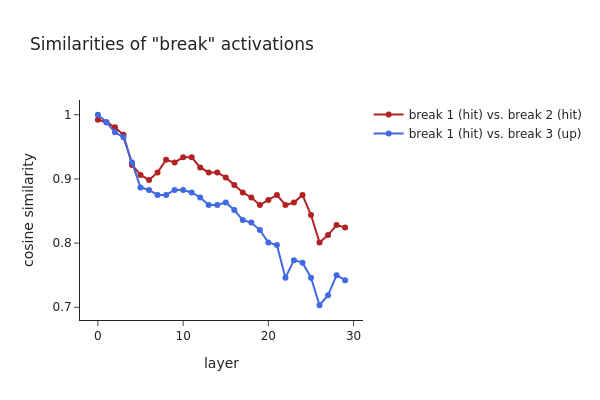

In [25]:
import plotly.graph_objects as go
import torch

with model.trace("The package is very fragile - it will break easily"):
  # loop through all the layers to get their activations
  break_one = [layer.output[0, -2] for layer in model.model.layers].save()

with model.trace("If you throw the ball at the window you might break it"):
  # loop through all the layers to get their activations
  break_two = [layer.output[0, -2] for layer in model.model.layers].save()

with model.trace("This relationship is hard and I think we should break up"):
  break_three = [layer.output[0, -2] for layer in model.model.layers].save()

# we can use cosine distance to measure how similar the activations are
cosine_similarities_one_vs_two = [
    torch.nn.functional.cosine_similarity(act_one, act_two, dim=0).item()
    for act_one, act_two in zip(break_one, break_two)
]

cosine_similarities_one_vs_three = [
    torch.nn.functional.cosine_similarity(act_one, act_three, dim=0).item()
    for act_one, act_three in zip(break_one, break_three)
]

fig = go.Figure()

# plot similarities between the two physical breaks
fig.add_trace(go.Scatter(
    x=list(range(len(model.model.layers))),
    y=cosine_similarities_one_vs_two,
    mode='lines+markers',
    name='break 1 (hit) vs. break 2 (hit)',
    line=dict(color='firebrick', width=2)
))

# add similarity between physical break and figurative break up
fig.add_trace(go.Scatter(
    x=list(range(len(model.model.layers))),
    y=cosine_similarities_one_vs_three,
    mode='lines+markers',
    name='break 1 (hit) vs. break 3 (up)',
    line=dict(color='royalblue', width=2) # Dashed line
))

fig.update_layout(
    title='Similarities of \"break\" activations',
    xaxis_title='layer',
    yaxis_title='cosine similarity'
)

fig.update_layout(template="simple_white", width=600, height=400)

fig.show()

Here are a few things to notice about the plot above:
* **Embeddings at layer 0 are all the same**. At this stage, the model processes the word itself, and doesn't incorporate the surrounding context.
* **Embeddings at the end are rather different**. At this stage, all the model cares about is predicting the next token - the more similar the next token distributions are, the closer the cosine embeddings will get.
* **Semantic similarity happens at the middle layers.** The three versions of "break" we looked at are all distinct - the first is intransitive (the package breaks by itself), the second is transitive (the ball breaks the window), and the third is figurative (break up). While the first & the second are different in their *syntax*, the first & the third are different in their *semantics*. This gets reflected most clearly around layer 10 in our case.

### ✏ **Exercise 3**

Can you find a sense of "break" that's different from both "breaking a window" and "breaking up"?

Change **only** the code in the box below to find a use of break whose representation has a cosine similarity **between 0.7 and 0.8** compared with the other uses of break.

*Hint: look at [this paper](https://aclanthology.org/2023.findings-eacl.36.pdf) for inspiration!*

In [26]:
with model.trace("If you throw the ball at the window you might break it"):
  break_window = model.model.layers[10].output[0, -2].save()

with model.trace("This relationship is hard and I think we should break up"):
  break_up = model.model.layers[10].output[0, -2].save()

###################### YOUR CODE HERE #########################
with model.trace("YOUR SENTENCE HERE"):
  # remember to change the token position (-2), but NOT the layer (10) !
  your_break = model.model.layers[10].output[0, -2].save()
###############################################################

print(
  "break (window) vs. break (yours):",
  torch.nn.functional.cosine_similarity(break_window, your_break, dim=0).item()
)

print(
  "break (up) vs. break (yours):",
  torch.nn.functional.cosine_similarity(break_up, your_break, dim=0).item()
)

break (window) vs. break (yours): 0.51953125
break (up) vs. break (yours): 0.482421875


What sentence did you use? Why do you think it has the similarity that it has?

> FILL IN YOUR ANSWER HERE

### The MLP layer

Now that we understand the input and output of each layer in our model (the residual stream), we can peel back another layer and look at individual components within the layer. We'll focus on two:
1. MLP: dense processing layers.
2. Attention: move information between different tokens.

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/mlp.png" width="500" alt="lm one layer"/>

Each layer in a language model has two core components: an **attention layer** and a **multi-layer perceptron (MLP)**.

In [26]:
model.model.layers[10]

LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=576, out_features=576, bias=False)
    (k_proj): Linear(in_features=576, out_features=192, bias=False)
    (v_proj): Linear(in_features=576, out_features=192, bias=False)
    (o_proj): Linear(in_features=576, out_features=576, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=576, out_features=1536, bias=False)
    (up_proj): Linear(in_features=576, out_features=1536, bias=False)
    (down_proj): Linear(in_features=1536, out_features=576, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((576,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((576,), eps=1e-05)
)

These components are responsible for different operations. In particular,

* **MLPs** store and process information. This is by far the most dense part of the model (it has the most parameters dedicated to it). Facts recalled by the model, and computational processing of these facts, are stored in the MLP layers.
* **Attention** components move information between tokens. This is an important point! MLPs can only work on the token in front of them - information that comes from the rest of the context can only be brought in by attention heads.

You can think of an MLP as a smaller neural network embedded within the large transformer block. These neural networks are **dense** - MLP layers have many more parameters than the rest of the network. It's reasonable to hypothesize that facts recalled by the model are stored in the MLP layers.

Let's count the number of parameters in the MLP at layer 10.

In [27]:
mlp_components = [
    parameter for name, parameter in model.model.layers[10].named_parameters()
    if "mlp" in name
]

# get the number of weights (number of numbers) of each MLP component
num_parameters = sum(p.numel() for p in mlp_components)

print("Number of parameters in MLP at layer 10:", num_parameters)

Number of parameters in MLP at layer 10: 2654208


Layer 10 alone has more than 2 million parameters! How does this compare to the attention components in layer 10?

In [28]:
attn_components = [
    parameter for name, parameter in model.model.layers[10].named_parameters()
    if "attn" in name
]

# get the number of weights (number of numbers) of each MLP component
num_parameters = sum(p.numel() for p in attn_components)

print("Number of parameters in attention at layer 10:", num_parameters)

Number of parameters in attention at layer 10: 884736


We can see that the MLP layers have nearly an order of magnitude more parameters dedicated to them than attention layers.

MLP activations are also sparse. That is, when we pass in an input vector to the MLP, only a few neurons in the MLP activation "light up". To see this, let's look at the intermediate MLP output on the token "Paris" in "The city Paris is in France" across all layers in our model.

Number of neurons of MLP activation in a single layer: 576


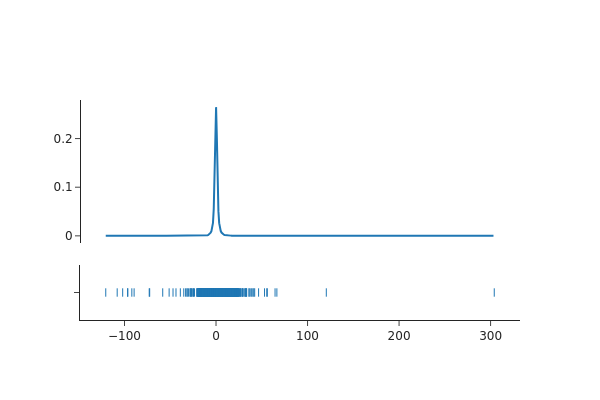

In [37]:
# MLP activations are sparse!
import plotly.figure_factory as ff

# let's compare the model's representation of Paris across different contexts
with model.trace("The city Paris is in France"):
  # get the output of the 3rd token in the sequence (index 2)
  mlp_activations = [layer.mlp.output[0, 2] for layer in model.model.layers].save()

fig = ff.create_distplot(
    [[a.item() for mlp_activation in mlp_activations for a in mlp_activation]],
    group_labels=['dist_plot'],
    show_hist=False,
)

fig.update_layout(
    width=600,
    height=400,
    showlegend=False,
    template="simple_white"
)

print("Number of neurons of MLP activation in a single layer:", len(mlp_activations[0]))

fig.show()

The plot above show the distribution over different activation values for neurons in the MLP layer. Notice how nearly all values are around 0, but there's a single neuron with an activation value over $300$! As we'll learn in later chapters, just because an activation is large doesn't necessarily mean it has a causal effect on the model's output. Nevertheless, it's good to note that very few of the MLP activation's neurons take on very large values.

One interpretation for the sparsity of MLP activations suggests that one of the roles these components play is factual recall. If neuron #314 only lights up when Paris is in the input and nothing else, we might hypothesize that this neuron is storing some fact about Paris. Seeing as MLP layers comprise the vast majority of the model, and that the MLP neurons behave in this selective way where they only activate on specific inputs, it seems likely that factual recall is one of the roles of MLP components.

### ✏ **Exercise 4**

Follow the code we set up above to compute the **percentage of parameters that come from MLP layers in the model**. How much of the model is just MLP layers?

*Hint: use `model.named_parameters()` to get a list of all of the parameters in the model.*

What percentage of the model is made up of MLP layers? Hypothesize functions or capabilities of the model that would require lots of parameters dedicated to them besides factual recall.

> FILL IN YOUR ANSWER HERE

### Attention

So far, we've seen how information moves in the residual stream from left to right - the activation of "Eiffel" affects the activation of "Tower", but not the other way around! - and how MLP layers might process and recall certain information for each token. But what component actually moves this information from token to token? How does the activation of "in" for the sentence "The Eiffel Tower is in" receive information from "Eiffel" and "Tower"?

The **attention** component is the **only** component in the model responsible for moving information from token to token - without it, the model would have no way to process whole sentences!

<img src="https://raw.githubusercontent.com/cs221m/cs221m-course/refs/heads/main/figures/lecture_02_review_of_lms/attention.png" width="1000" alt="lm one layer"/>

The attention component moves information from one token to the other by letting each token take a **weighted sum** of the (projected) activations of its previous tokens. There's three components in the attention mechanism that work together to let tokens "attend" to each other:
* **query** projection $Q_{\text{proj}}$: projects the activation over each token to a "query" vector
* **key** projection $K_{\text{proj}}$: projects the activation over each token to a "key" vector; the more similar the key & query vectors are, the more information gets moved from the key token to the query token
* **value** projection $V_{\text{proj}}$: decodes the "value" that gets read from each activation (think of this as a light "processing" layer)

After projecting each token's activation to form a **key** and a **query**, the model computes an **attention map** for how close every key is to every query:

$$
QK_{i, j} = k_i \cdot q_j
$$

The closer the query is to the key, the more that token $j$ "attends" to token $i$. In the figure, we can see that "Tower" attends closely to "Eiffel" but not to "the". Note that the bottom half of the attention map is empty - tokens can't look ahead to future tokens in the sequence! This explains why the representation of Paris is identical between the sentences "The city of Paris is in London" and "The city of Paris is in France" (but different between "The capital of London/France is Paris").

The attention map determines which information flows from which tokens. After applying a column-wise *softmax* function (just as we did for the output logits of our language model), we get a distribution over previous tokens. We use this distribution to compute a weighted average of the value projections for each activation.
$$
h_j = \sum_{i \leq j} \texttt{softmax}(QK)_j \cdot v_i
$$

where $h_j$ is the output of the attention layer for token $j$, and $v_i$ is the value projection for token $i \leq j$.

Although we won't get into exact implementation details, we can see (and access) the intermediate values $q$, $k$, and $v$ in the source code of our model!

In [38]:
print(model.model.layers[10].self_attn.source)

                                             * def forward(
                                             0     self,
                                             1     hidden_states: torch.Tensor,
                                             2     position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
                                             3     attention_mask: torch.Tensor | None = None,
                                             4     past_key_values: Cache | None = None,
                                             5     cache_position: torch.LongTensor | None = None,
                                             6     **kwargs: Unpack[TransformersKwargs],
                                             7 ) -> tuple[torch.Tensor, torch.Tensor]:
                                             8     input_shape = hidden_states.shape[:-1]
                                             9     hidden_shape = (*input_shape, -1, self.head_dim)
                                 

We can display the attention map by collecting the value for `attn_weights` (the $QK$ matrix after applying softmax to it). Each column $t$ of `attn_weights` gives us the probability distribution for which tokens the activation at token $t$ "attends" to. Remember that only the attention map is asymmetric - it reports how the tokens on the x-axis attend to the tokens on the y-axis.

Already, we can pick up on an important part of the model: **induction heads**. LLMs are very good at copying sequences within their context, and researchers propose that this copying mechanism drives the pattern-matching behavior of LLMs in many in-context learning tasks.

In [61]:
model.config._attn_implementation = "eager" # this is the attention implementation we described above!
prompt = "a is a & b is b & c is c & d is"

with model.trace(prompt):
  outputs = model.model.layers[10].self_attn.source.attention_interface_0.output.save()

attn_outputs, attn_weights = outputs

attn_weights.shape

torch.Size([1, 9, 14, 14])

Modern language models have multiple attention heads at each layer (in our case, the model has 9 heads in each layer). Each attention head has its own attention map, moving information from a combination of previous tokens.

Looking at head #3 in layer 10, we can see an interesting attention pattern: the second "b" in "b & b" attends to the first one; the second "c" attends to the first. Similarly, tokens at "&" attend to "is" and tokens at "is" attend to "&". This attention pattern looks like a diagonal that's two steps away from the central diagonal - each token attends to the token two positions before it! 

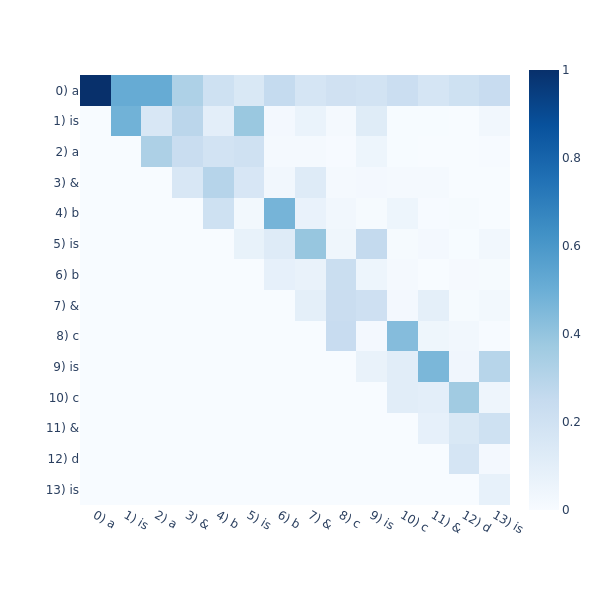

In [62]:
import plotly.express as px

tokens =[t.replace('Ġ', '') for t in model.tokenizer.tokenize(prompt)]

fig = px.imshow(
    # look at attention head #3
    attn_weights[0, 3].detach().cpu().float().T,
    x=[f"{i}) {l}" for i, l in enumerate(tokens)],
    y=[f"{i}) {l}" for i, l in enumerate(tokens)],
    width=600,
    height=600,
    color_continuous_scale="Blues"
)

fig.show()

### ✏ **Exercise 5**

Flip through different attention heads at different layers. Do you notice any interesting attention patterns?

One attention pattern to look for is an "attention sink" - all tokens attend to the first token in the sequence (it can often even be a pad token!). Can you find an attention head that behaves in this way?

*Hint: attention sinks "throw away" or ignore information - which layers might that happen in?*

Name a layer and head index where all tokens "attend" to the same token. Describe what this attention map means for the attention output for that head. Why do you think a transformer model might learn to implement some attention heads in this way?

> FILL IN YOUR ANSWER HERE

### 🧠 Takeaways

We hope that this was a helpful review on the components of modern-day language models! Starting with language model interactions and ending with individual components, we hope you got a refresher on transformers with an eye towards understanding their inner workings.

As we prepare to take a deeper look into how language models represent and process information, we hope you keep the following takeaways in mind.
* **Language models work one token at a time**: language models work by predicting the distribution of the next token given the sequence of tokens that precedes it. This means they must move all relevant information from the input to the last layer of the last token before they make their next prediction!  
* **Language models are autoregressive**: as we saw, the output of a language model - and its internal activations - strictly depend on the prior context in its input. Intermediate activations can't "look ahead" to future tokens in the sequence in order to inform their computation.
* **MLPs store information & attention moves information**: nothing else in the model can move information across tokens! If you ever see a model recalling something from earlier in the context, know that attention was involved. In a way, we can think of MLPs as long-term memory and attention as short-term (working) memory.

Now that we feel comfortable with language models and their internals, we'll start on our journey towards understanding their internal computations. In the next lecture, we'll go "outside in". Introducing behavioral analysis, we'll see how we can make predictions about the internal representations of language models through understanding their behavior.